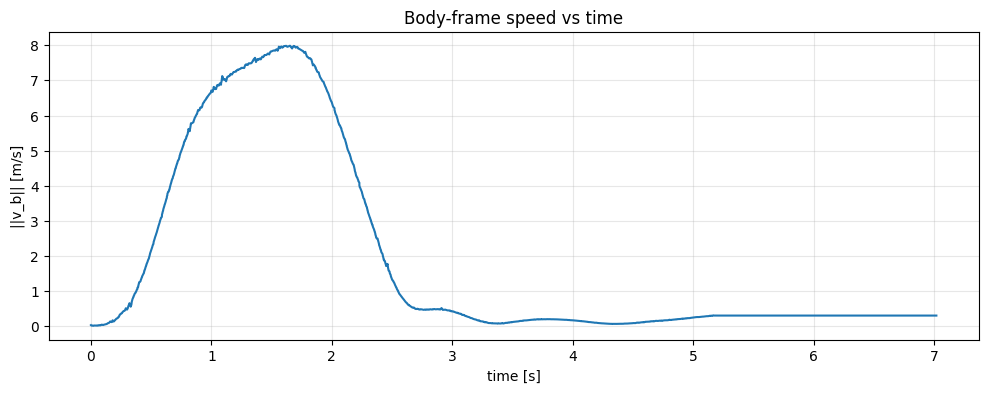

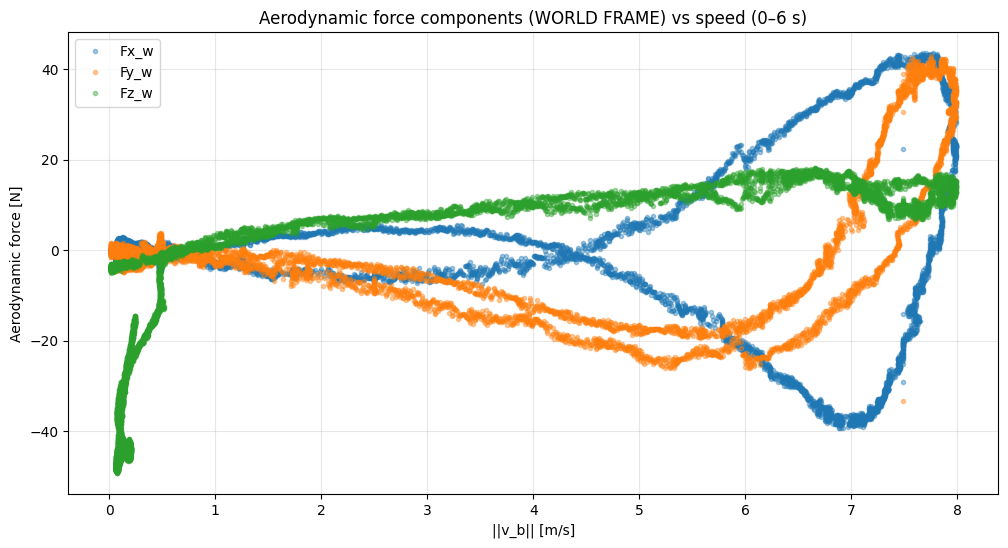

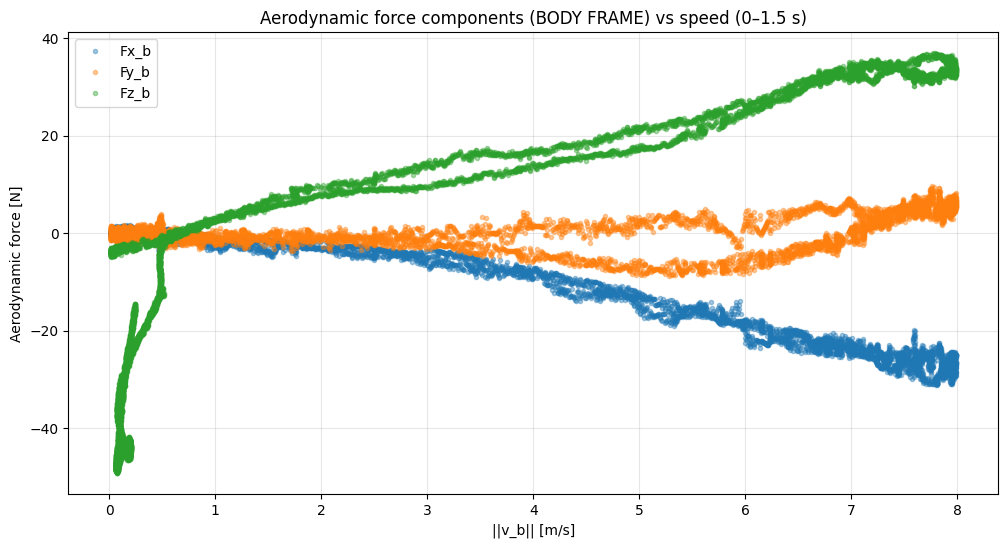

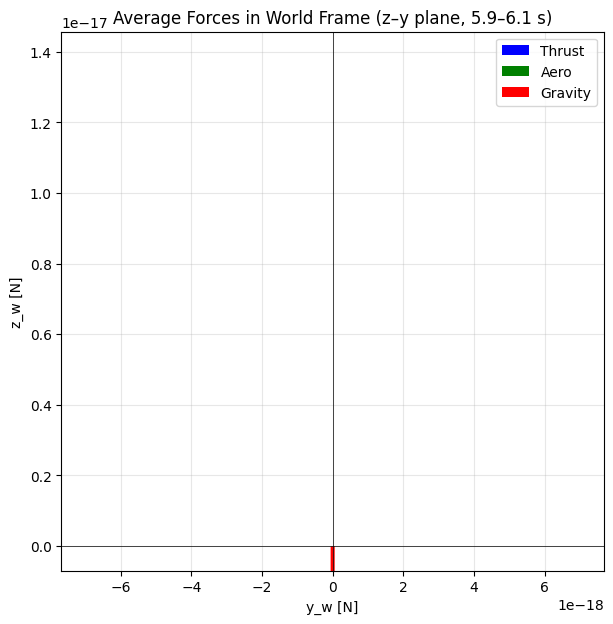

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transforms3d.quaternions import quat2mat

# ------------------------------------------------------------
# 1. Load Data
# ------------------------------------------------------------

data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/8mps_imu")

def load_series(filename, col):
    df = pd.read_csv(data_dir / filename)
    return df[["elapsed time", "value"]].rename(columns={"elapsed time": "t", "value": col})

# --- IMU specific force (body)
ax = load_series("linear_acceleration_x.csv", "ax_b")
ay = load_series("linear_acceleration_y.csv", "ay_b")
az = load_series("linear_acceleration_z.csv", "az_b")

# --- Orientation (quaternion, world)
qx = load_series("pos_orientation_x.csv", "qx_w")
qy = load_series("pos_orientation_y.csv", "qy_w")
qz = load_series("pos_orientation_z.csv", "qz_w")
qw = load_series("pos_orientation_w.csv", "qw_w")

# --- Velocity (world)
vx = load_series("twist_linear_x.csv", "vx_w")
vy = load_series("twist_linear_y.csv", "vy_w")
vz = load_series("twist_linear_z.csv", "vz_w")

# --- Motor rpm
rpm = load_series("average_motor_speed.csv", "rpm")
rpm["rpm"] *= 10

# Merge all into one dataframe
dfs = [ax, ay, az, qx, qy, qz, qw, vx, vy, vz, rpm]
df = dfs[0]
for d in dfs[1:]:
    df = pd.merge(df, d, on="t", how="outer")
df = df.sort_values("t").interpolate().reset_index(drop=True)

# ------------------------------------------------------------
# 2. Basic constants + rotation helpers
# ------------------------------------------------------------

mass = 2.5
g = 9.81
g_world = np.array([0, 0, -g])

def R_wb(qw, qx, qy, qz):
    R_bw = quat2mat([qw, qx, qy, qz])  # body->world
    return R_bw.T  # world->body

# ------------------------------------------------------------
# 3. Compute thrust + aerodynamic force in body frame
# ------------------------------------------------------------

def thrust_per_motor(rpm):
    return 5.15e-8 * rpm**2 - 0.09e-3 * rpm

T_total = 4 * thrust_per_motor(df["rpm"].to_numpy())
F_thrust_b = np.zeros((len(df), 3))
F_thrust_b[:, 2] = T_total

# IMU specific force f_b
f_b = df[["ax_b", "ay_b", "az_b"]].to_numpy()

# Total non-grav force = m f_b
F_sum_b = mass * f_b

# Aero force in body frame
F_aero_b = F_sum_b - F_thrust_b

# ------------------------------------------------------------
# 4. Rotate forces to world frame
# ------------------------------------------------------------

F_thrust_w = np.zeros_like(F_thrust_b)
F_aero_w   = np.zeros_like(F_thrust_b)
F_g_w      = np.zeros_like(F_thrust_b)
F_g_w[:]   = mass * g_world

for i, row in df.iterrows():
    Rwb = R_wb(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    Rbw = Rwb.T
    F_thrust_w[i] = Rbw @ F_thrust_b[i]
    F_aero_w[i]   = Rbw @ F_aero_b[i]

# ------------------------------------------------------------
# 5. Compute body-frame speed magnitude
# ------------------------------------------------------------

V_b = []
for _, row in df.iterrows():
    Rwb = R_wb(row["qw_w"], row["qx_w"], row["qy_w"], row["qz_w"])
    v_w = np.array([row["vx_w"], row["vy_w"], row["vz_w"]])
    v_b = Rwb @ v_w
    V_b.append(np.linalg.norm(v_b))
V_b = np.array(V_b)

t_rel = df["t"] - df["t"].min()

# ------------------------------------------------------------
# PLOT 0: Velocity vs time
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(t_rel, V_b)
plt.xlabel("time [s]")
plt.ylabel("||v_b|| [m/s]")
plt.title("Body-frame speed vs time")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 6. PLOT 1: Aerodynamic forces vs speed (0–6 s window)
# ------------------------------------------------------------

mask = (t_rel >= 0) & (t_rel <= 5)

V_b_win = V_b[mask]
Fx_w = F_aero_w[mask, 0]
Fy_w = F_aero_w[mask, 1]
Fz_w = F_aero_w[mask, 2]

plt.figure(figsize=(12, 6))
plt.plot(V_b_win, Fx_w, ".", alpha=0.4, label="Fx_w")
plt.plot(V_b_win, Fy_w, ".", alpha=0.4, label="Fy_w")
plt.plot(V_b_win, Fz_w, ".", alpha=0.4, label="Fz_w")
plt.xlabel("||v_b|| [m/s]")
plt.ylabel("Aerodynamic force [N]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Aerodynamic force components (WORLD FRAME) vs speed (0–6 s)")
plt.show()

# Body-frame aerodynamic forces in same window
Fx_b = F_aero_b[mask, 0]
Fy_b = F_aero_b[mask, 1]
Fz_b = F_aero_b[mask, 2]

plt.figure(figsize=(12, 6))
plt.plot(V_b_win, Fx_b, ".", alpha=0.4, label="Fx_b")
plt.plot(V_b_win, Fy_b, ".", alpha=0.4, label="Fy_b")
plt.plot(V_b_win, Fz_b, ".", alpha=0.4, label="Fz_b")
plt.xlabel("||v_b|| [m/s]")
plt.ylabel("Aerodynamic force [N]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Aerodynamic force components (BODY FRAME) vs speed (0–1.5 s)")
plt.show()
# ------------------------------------------------------------
# 7. PLOT 2: Average force vectors in world z–y plane (5.9–6.1 s)
# ------------------------------------------------------------

mask_avg = (t_rel >= 0) & (t_rel <= 10)

Ft_mean = F_thrust_w[mask_avg].mean(axis=0)
Fa_mean = F_aero_w[mask_avg].mean(axis=0)
Fg_mean = F_g_w[mask_avg].mean(axis=0)

y0, z0 = 0.0, 0.0
scale = 1.0

plt.figure(figsize=(7, 7))
plt.quiver(y0, z0, Ft_mean[1]*scale, Ft_mean[2]*scale, color="blue",  label="Thrust",
           angles="xy", scale_units="xy", scale=1)
plt.quiver(y0, z0, Fa_mean[1]*scale, Fa_mean[2]*scale, color="green", label="Aero",
           angles="xy", scale_units="xy", scale=1)
plt.quiver(y0, z0, Fg_mean[1]*scale, Fg_mean[2]*scale, color="red",   label="Gravity",
           angles="xy", scale_units="xy", scale=1)

plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel("y_w [N]")
plt.ylabel("z_w [N]")
plt.title("Average Forces in World Frame (z–y plane, 5.9–6.1 s)")
plt.legend()
plt.axis("equal")
plt.show()

# Body-frame average forces over mask_avg (same as world-frame)
Ft_mean_b = F_thrust_b[mask_avg].mean(axis=0)
Fa_mean_b = F_aero_b[mask_avg].mean(axis=0)

# Gravity in body frame: you already have gx_b, gy_b, gz_b
Fg_b = np.vstack([
    combined["gx_b"].to_numpy(),
    combined["gy_b"].to_numpy(),
    combined["gz_b"].to_numpy()
]).T * mass
Fg_mean_b = Fg_b[mask_avg].mean(axis=0)

# x–z plane origin
x0, z0 = 0.0, 0.0
scale = 1.0

plt.figure(figsize=(7, 7))

# Thrust (body, x–z)
plt.quiver(
    x0, z0,
    Ft_mean_b[0] * scale, Ft_mean_b[2] * scale,
    color="blue", label="Thrust (body)",
    angles="xy", scale_units="xy", scale=1
)

# Aero (body, x–z)
plt.quiver(
    x0, z0,
    Fa_mean_b[0] * scale, Fa_mean_b[2] * scale,
    color="green", label="Aero (body)",
    angles="xy", scale_units="xy", scale=1
)

# Gravity (body, x–z)
plt.quiver(
    x0, z0,
    Fg_mean_b[0] * scale, Fg_mean_b[2] * scale,
    color="red", label="Gravity (body)",
    angles="xy", scale_units="xy", scale=1
)

plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel("x_b [N]")
plt.ylabel("z_b [N]")
plt.title("Average Forces in Body Frame (x–z plane, same interval)")
plt.legend()
plt.axis("equal")
plt.show()

